# 3.5 & 3.6 エビデンス近似と固定基底関数の限界 (The Evidence Approximation & Limitations)

本ノートブックでは、ハイパーパラメータ（正則化係数やノイズ精度）をデータから完全に自動決定する**エビデンス近似（経験ベイズ / Empirical Bayes / Type II 最尤法）**の理論と実装、および固定基底関数モデルが直面する本質的な限界を扱います。
有効パラメータ数 $\gamma$ の幾何学的意味、反復自己無撞着更新アルゴリズムの実装、**PRML Figure 3.16, 3.17** の再現、そしてニューラルネットワークやカーネル法へ続く動機づけ（3.6節）を学びます。

## 3.5.1 & 3.5.2 エビデンス近似の理論的枠組みと最大化

完全なベイズアプローチでは、ハイパーパラメータ $\alpha$ および $\beta$ に対しても超事前分布を導入し、周辺化積分を行いますが、事後分布 $p(\alpha, \beta | \mathbf{t})$ が鋭いピークを持つ場合、**エビデンス関数（周辺尤度）$p(\mathbf{t} | \alpha, \beta)$ を最大化する点推定**を行うことが極めて有効な近似（エビデンス近似 / 経験ベイズ）となります。

### 対数エビデンス関数 (Log Evidence Function)
$$ \ln p(\mathbf{t} | \alpha, \beta) = \frac{M}{2} \ln \alpha + \frac{N}{2} \ln \beta - E(\mathbf{m}_N) - \frac{1}{2} \ln |\mathbf{A}| - \frac{N}{2} \ln(2\pi) $$
ここで
$$ E(\mathbf{m}_N) = \frac{\beta}{2} \|\mathbf{t} - \mathbf{\Phi} \mathbf{m}_N\|^2 + \frac{\alpha}{2} \mathbf{m}_N^T \mathbf{m}_N $$
$$ \mathbf{A} = \alpha \mathbf{I} + \beta \mathbf{\Phi}^T \mathbf{\Phi} $$

### ハイパーパラメータの更新式
行列 $\beta \mathbf{\Phi}^T \mathbf{\Phi}$ の固有値を $\lambda_i$ と置くと、行列 $\mathbf{A}$ の固有値は $\alpha + \lambda_i$ となります。
対数エビデンスの $\alpha$ および $\beta$ に関する停留条件を求めることで、以下の**自己無撞着方程式 (Self-consistent Equations)** が導かれます：

$$ \gamma = \sum_{i=1}^M \frac{\lambda_i}{\alpha + \lambda_i} $$
$$ \alpha = \frac{\gamma}{\mathbf{m}_N^T \mathbf{m}_N} $$
$$ \frac{1}{\beta} = \frac{1}{N - \gamma} \sum_{n=1}^N \{t_n - \mathbf{m}_N^T \boldsymbol{\phi}(\mathbf{x}_n)\}^2 $$

ここで $\gamma$ は**有効パラメータ数 (Effective Number of Parameters)** と呼ばれます。

## 3.5.3 有効パラメータ数 $\gamma$ の幾何学的解釈

なぜ $\gamma$ が「有効な」パラメータ数と呼ばれるのでしょうか？

- **$\lambda_i \gg \alpha$ の方向**:
  データによる制約が事前分布よりも圧倒的に強く、比率 $\frac{\lambda_i}{\alpha + \lambda_i} \approx 1$ となります。この方向のパラメータはデータによって確定的に拘束されています。
- **$\lambda_i \ll \alpha$ の方向**:
  データがほとんど情報を持たず事前分布が支配的となり、比率 $\frac{\lambda_i}{\alpha + \lambda_i} \approx 0$ となります。この方向のパラメータはデータによって更新されていません。

したがって、総和 $\gamma = \sum_i \frac{\lambda_i}{\alpha + \lambda_i}$ は、$M$ 個の全パラメータのうち**データによって実際に意味のある値として決定されたパラメータの有効な自由度**を表しています。

Optimal alpha: 1.8687
Optimal beta:  24.9035 (True beta: 25.0)
Effective parameters gamma: 4.960 / 10


Plot saved to: result/fig3_16_evidence_convergence.png


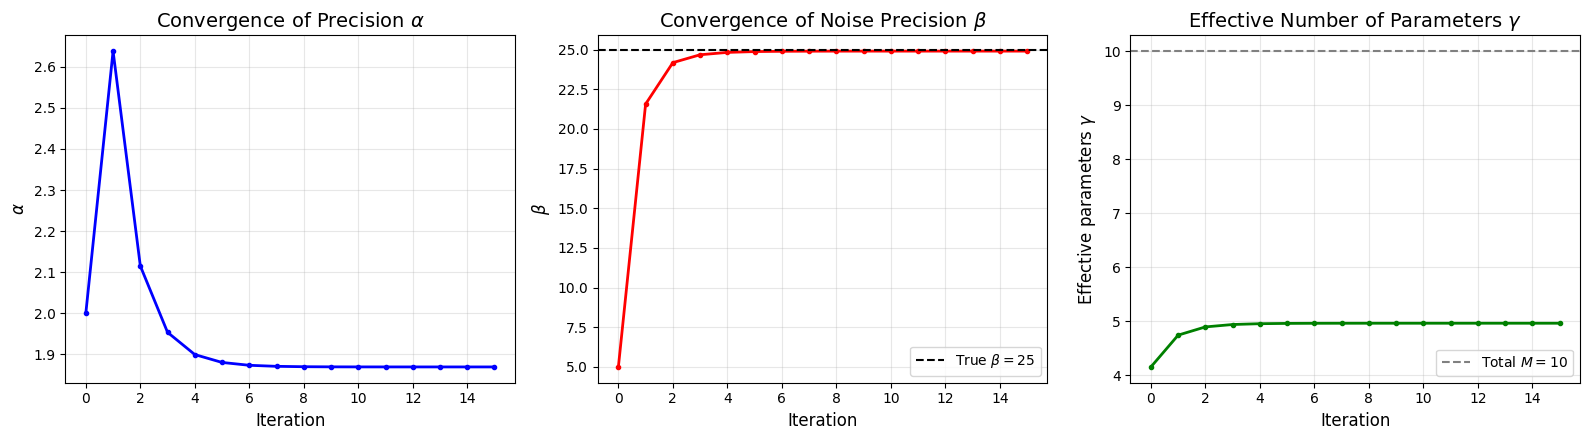

In [1]:
import sys, os
sys.path.append(os.path.abspath('../'))
import numpy as np
import matplotlib.pyplot as plt
from common.plot_utils import save_plot, setup_style
from common.regression_utils import GaussianBasis, PolynomialBasis, EvidenceApproximation, BayesianLinearRegression
setup_style()

np.random.seed(42)

# データ生成: sin(2 * pi * x) + noise
N = 30
x_data = np.sort(np.random.uniform(0, 1, N))
beta_true = 25.0 # sigma = 0.2
t_data = np.sin(2 * np.pi * x_data) + np.random.normal(0, 1.0 / np.sqrt(beta_true), N)

# ガウス基底関数 (M=9)
centers = np.linspace(0, 1, 9)
scale = 0.2
basis = GaussianBasis(centers=centers, scale=scale)
Phi = basis(x_data)

# エビデンス近似の反復実行
ev = EvidenceApproximation(max_iter=60, tol=1e-6)
ev.fit(Phi, t_data, init_alpha=2.0, init_beta=5.0)

print(f"Optimal alpha: {ev.alpha:.4f}")
print(f"Optimal beta:  {ev.beta:.4f} (True beta: {beta_true})")
print(f"Effective parameters gamma: {ev.gamma:.3f} / {Phi.shape[1]}")

# 収束推移のプロット (PRML Figure 3.16 的な推移)
iters = [h['iter'] for h in ev.history]
alphas = [h['alpha'] for h in ev.history]
betas = [h['beta'] for h in ev.history]
gammas = [h['gamma'] for h in ev.history]

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

axes[0].plot(iters, alphas, 'b.-', lw=2)
axes[0].set_xlabel('Iteration')
axes[0].set_ylabel(r'$\alpha$')
axes[0].set_title(r'Convergence of Precision $\alpha$')
axes[0].grid(True, alpha=0.3)

axes[1].plot(iters, betas, 'r.-', lw=2)
axes[1].axhline(beta_true, color='k', linestyle='--', label=r'True $\beta = 25$')
axes[1].set_xlabel('Iteration')
axes[1].set_ylabel(r'$\beta$')
axes[1].set_title(r'Convergence of Noise Precision $\beta$')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

axes[2].plot(iters, gammas, 'g.-', lw=2)
axes[2].axhline(Phi.shape[1], color='gray', linestyle='--', label=r'Total $M = 10$')
axes[2].set_xlabel('Iteration')
axes[2].set_ylabel(r'Effective parameters $\gamma$')
axes[2].set_title(r'Effective Number of Parameters $\gamma$')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
save_plot(fig, 'result', 'fig3_16_evidence_convergence.png')
plt.show()

Plot saved to: result/fig3_17_evidence_and_gamma.png


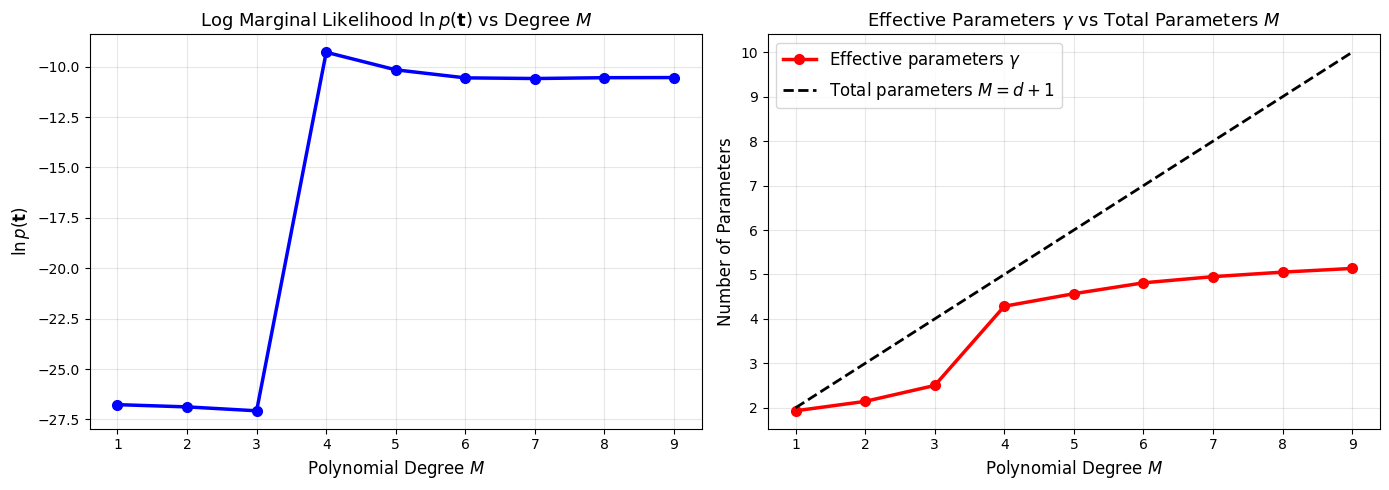

In [2]:
# PRML Figure 3.17 の再現: 多項式次数 M に対する log evidence, gamma, test error
degrees = list(range(1, 10))
evidences = []
gammas_deg = []
w_norms = []

for deg in degrees:
    poly = PolynomialBasis(degree=deg)
    Phi_deg = poly(x_data)
    
    # 最適 alpha, beta の探索
    ev_deg = EvidenceApproximation(max_iter=100, tol=1e-5).fit(Phi_deg, t_data, init_alpha=1.0, init_beta=10.0)
    
    # 対数エビデンスの計算
    blr = BayesianLinearRegression(alpha=ev_deg.alpha, beta=ev_deg.beta).fit(Phi_deg, t_data)
    log_ev = blr.log_marginal_likelihood()
    
    evidences.append(log_ev)
    gammas_deg.append(ev_deg.gamma)
    w_norms.append(np.sqrt(np.sum(ev_deg.m_N**2)))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 対数エビデンス
axes[0].plot(degrees, evidences, 'bo-', lw=2.5, markersize=7)
axes[0].set_title(r'Log Marginal Likelihood $\ln p(\mathbf{t})$ vs Degree $M$', fontsize=13)
axes[0].set_xlabel('Polynomial Degree $M$')
axes[0].set_ylabel(r'$\ln p(\mathbf{t})$')
axes[0].set_xticks(degrees)
axes[0].grid(True, alpha=0.3)

# 有効パラメータ数 gamma vs 全パラメータ数 M
axes[1].plot(degrees, gammas_deg, 'ro-', lw=2.5, markersize=7, label=r'Effective parameters $\gamma$')
axes[1].plot(degrees, [d + 1 for d in degrees], 'k--', lw=2, label=r'Total parameters $M = d + 1$')
axes[1].set_title(r'Effective Parameters $\gamma$ vs Total Parameters $M$', fontsize=13)
axes[1].set_xlabel('Polynomial Degree $M$')
axes[1].set_ylabel('Number of Parameters')
axes[1].set_xticks(degrees)
axes[1].legend(fontsize=12)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
save_plot(fig, 'result', 'fig3_17_evidence_and_gamma.png')
plt.show()

## 3.6 固定基底関数の限界 (Limitations of Fixed Basis Functions)

ここまで線形基底関数モデルを詳細に学んできましたが、このモデルには機械学習の実践において極めて深刻な限界があります。

### 1. 次元の呪い (Curse of Dimensionality)
基底関数 $\phi_j(\mathbf{x})$ は**データを観測する前にあらかじめ固定**されています。
$D$ 次元の入力空間を一様に覆う局所基底関数（ガウス基底など）を配置する場合、各軸に $K$ 個の基底を配置すると必要な基底の総数は
$$ M = K^D $$
となり、$D$ に対して指数関数的に爆発します。例えば $D=10, K=10$ の場合、必要な基底関数は $10^{10} = 100$ 億個となり、計算もメモリも破綻します。

### 2. 救いとなる現実のデータの性質
幸いにも、現実世界の多くのデータセットは以下の2つの重要な性質を持っています：
1. **データ多様体 (Data Manifold)**:
   入力変数間に強い相関が存在するため、データ点 $\{\mathbf{x}_n\}$ は高次元空間 $\mathbb{R}^D$ の全体に散らばるのではなく、本質的次元がはるかに低い非線形多様体の近傍に集中しています。
2. **目的変数の低次元依存性**:
   目的変数 $t$ は、多様体内のごく少数の特定の方向の変化にのみ強く依存します。

### 次章以降への展望
固定された基底関数に代わり、データから学習できる適応的な基底関数を用いることでこの限界を打破します：
- **第5章 ニューラルネットワーク (Neural Networks)**:
  パラメータを持つ適応的基底関数（隠れ層ユニット）を用い、入力空間の重要な方向やデータ多様体の構造をデータから直接学習します。
- **第6章・第7章 サポートベクトルマシン / カーネル法 (Kernel Methods)**:
  データ点数 $N$ のみのグラム行列で定式化し、無限次元の特徴空間を計算可能にします。